In [1]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('../MERS/')

## 1. Generate TOD with chromatic RHINO beam

In [2]:
from astropy.coordinates import EarthLocation, AltAz, SkyCoord
from astropy.time import Time
import astropy.units as u
import healpy as hp

# === JBO site ===
lat = 53.23625  # degrees
lon = -2.30744  # degrees
location = EarthLocation(lat=lat*u.deg, lon=lon*u.deg)

# === Generate obs_time list（UTC）===
# From 2024-10-01 22:00 to 2024-10-02 05:00，every "delta_minutes" minute
start_time = Time('2024-10-01 22:00:00', scale='utc', location=location)
end_time   = Time('2024-10-02 05:00:00', scale='utc', location=location)
delta_minutes = 2

# Construct the time sequence
times = start_time + np.arange(0, (end_time - start_time).to_value('min') + delta_minutes, delta_minutes) * u.min

# === Calculate the corresponding LSTs ===
lst_array = times.sidereal_time('mean', longitude=lon*u.deg)

# === Constants ===
Nside = 128  # HEALPix resolution
lat = 53.23625  # JBO latitude in degrees

# === Step 1: LSTs → (RA, Dec) for zenith ===
# Dec of zenith = latitude
dec_zenith = lat * u.deg
ra_zeniths = lst_array.to(u.deg)  # LST is the RA of the zenith

# === Step 2: Convert to Galactic coordinates ===
skycoords_eq = SkyCoord(ra=ra_zeniths, dec=dec_zenith, frame='icrs')
skycoords_gal = skycoords_eq.galactic

# === Step 3: Convert to HEALPix pixel indices ===
# Use vector representation to feed into healpy
vecs = skycoords_gal.represent_as('cartesian').get_xyz().value  # shape: (3, N)
pix_indices = hp.vec2pix(Nside, vecs[0], vecs[1], vecs[2])

In [3]:
from beam_model import RhinoBeam

freq_list = np.arange(55.0, 85.0+0.5, 0.5)
Nfreq = len(freq_list)


# Load the RHINO wet soil beam
RHINO_wet = RhinoBeam(filepath='/Users/zzhang/Dataspace/MERS/HornWet/')
RHINO_wet.get_beam_l()
RHINO_beam_window = RHINO_wet.bl_list

## Generate sky TOD

from fg_model import CNN_PL_sky, ptsrc_powerlaw
# Point source model initialization
ptsrc_model = ptsrc_powerlaw(nside=Nside)

def sky_TOD(beam_window=None, add_ptsrc=True, pix_indices=pix_indices):
    """
    Generate sky time-ordered data (TOD) for the given beam window function.
    
    Parameters:
    beam_window: list of ndarray
        Beam window functions for each frequency channel. Each element should be an array of shape (lmax+1,).
        If None, no beam is applied.
    add_ptsrc: bool
        Whether to include point sources in the sky model.
    
    Returns:
    sky_TOD: ndarray
        Time-ordered data of the sky, shape (Ntime, Nfreq).
    """

    # Diffuse + ptsrc sky model
    diffuse_sky, pivot_specidx_map = CNN_PL_sky(freq_list, beam_transfer=beam_window, nside=Nside, return_spec_index=True)
    
    if add_ptsrc:
        ptsrc_sky = ptsrc_model(freq_list, beam_transfer=beam_window)
        combined_sky = diffuse_sky + ptsrc_sky
    else:
        combined_sky = diffuse_sky

    if pix_indices is None: # Return full-sky map if no pixel indices are provided
        return combined_sky, pivot_specidx_map
    
    sky_TOD = combined_sky[pix_indices, :]  # shape: (Ntime, Nfreq)
    piv_spec_ind_TOD = pivot_specidx_map[pix_indices]  
    
    return sky_TOD, piv_spec_ind_TOD


sky_TOD_Rhino, pivot_specind_TOD = sky_TOD(beam_window=RHINO_beam_window)


## 2. Beam chromaticity methods

### 2.1 BCF method

In [4]:
def sky_map(ind,add_ptsrc=True):
    """
    Generate sky time-ordered  data (TOD) for the given beam window function.
    
    Parameters:
    add_ptsrc: bool
        Whether to include point sources in the sky model.
    
    Returns:
    sky_TOD: ndarray
        Time-ordered data of the sky, shape (Ntime, Nfreq).
    """

    # Diffuse + ptsrc sky model
    diffuse_sky, _ = CNN_PL_sky(freq_list, nside=Nside, return_spec_index=True)
    
    if add_ptsrc:
        ptsrc_sky = ptsrc_model(freq_list)
        combined_sky = diffuse_sky + ptsrc_sky
    else:
        combined_sky = diffuse_sky

    return combined_sky[:,ind]

In [5]:
# BCF
ref_beam_window = RHINO_wet.bl_list[30]
ref_map = sky_map(30,add_ptsrc=True)

RHINO_BCF_cube = np.array(RHINO_wet.generate_BCF(ref_map, ref_beam_window))

### 2.2 SVD beam

In [6]:
# SVD 
RHINO_U, RHINO_S, RHINO_Vh = RHINO_wet.generate_SVD_beams()
del RHINO_wet



/Users/zzhang/Workspace/MERS/notebooks/../MERS/beam_model.py:208: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


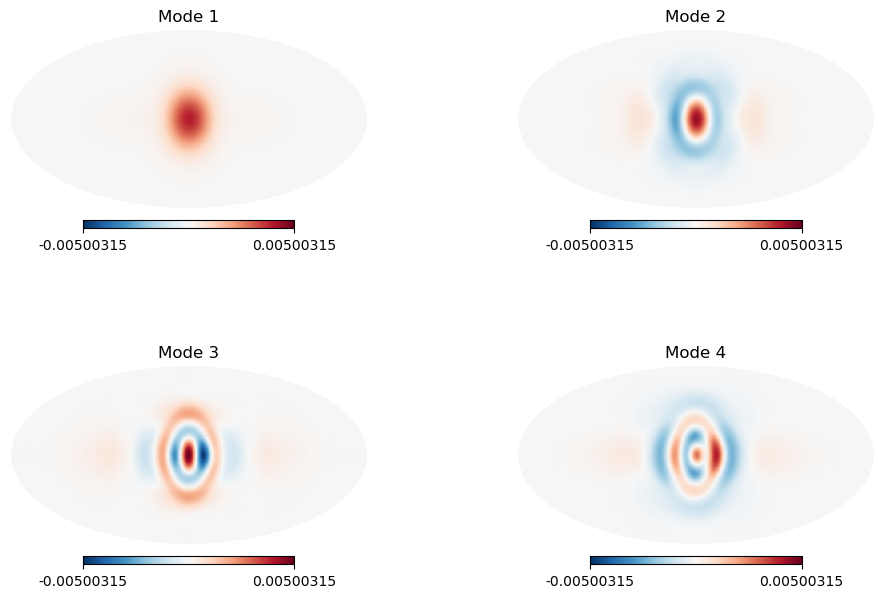

In [7]:
from beam_model import plot_svd_beam_modes

plot_svd_beam_modes(RHINO_Vh, nest=False)

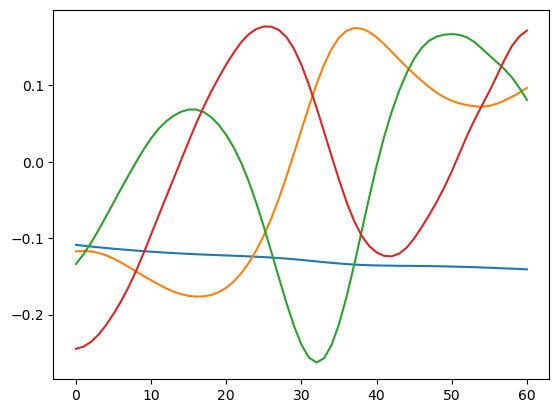

In [8]:
# First few SVD beam modesin frequency space

plt.plot(RHINO_U[:, :4])

### 2.3 Fitting Sky TOD (foregrounds) with beam chromaticity corrections 

In [9]:
from SEDfitting import fit_fg_cube

max_order = 6

RHINO_coeffs, RHINO_loss, RHINO_resi = fit_fg_cube(
    sky_TOD_Rhino, 
    pivot_specind_TOD, 
    freq_list, 
    nu_ref=None, 
    max_order=max_order, 
    adaptive_pivot=False, 
    remove_1st_moment=False,
    BCSVD=None, 
    BCF=None
)

RHINO_coeffs_BCF, RHINO_loss_BCF, RHINO_resi_BCF = fit_fg_cube(
    sky_TOD_Rhino, 
    pivot_specind_TOD, 
    freq_list, 
    nu_ref=None, 
    max_order=max_order, 
    adaptive_pivot=False, 
    remove_1st_moment=False,
    BCSVD=None, 
    BCF=RHINO_BCF_cube
)

n_beam = 2  # Number of SVD beam modes to use
RHINO_coeffs_SVD_2, RHINO_loss_SVD_2, RHINO_resi_SVD_2 = fit_fg_cube(
    sky_TOD_Rhino, 
    pivot_specind_TOD, 
    freq_list, 
    nu_ref=None, 
    max_order=max_order, 
    adaptive_pivot=False, 
    remove_1st_moment=False,
    BCSVD=RHINO_U[:, :n_beam], 
    BCF=None
)

n_beam = 3
RHINO_coeffs_SVD_3, RHINO_loss_SVD_3, RHINO_resi_SVD_3 = fit_fg_cube(
    sky_TOD_Rhino, 
    pivot_specind_TOD, 
    freq_list, 
    nu_ref=None, 
    max_order=max_order, 
    adaptive_pivot=False, 
    remove_1st_moment=False,
    BCSVD=RHINO_U[:, :n_beam], 
    BCF=None
)

n_beam = 6
RHINO_coeffs_SVD_6, RHINO_loss_SVD_6, RHINO_resi_SVD_6 = fit_fg_cube(
    sky_TOD_Rhino, 
    pivot_specind_TOD, 
    freq_list, 
    nu_ref=None, 
    max_order=max_order, 
    adaptive_pivot=False, 
    remove_1st_moment=False,
    BCSVD=RHINO_U[:, :n_beam], 
    BCF=None
)


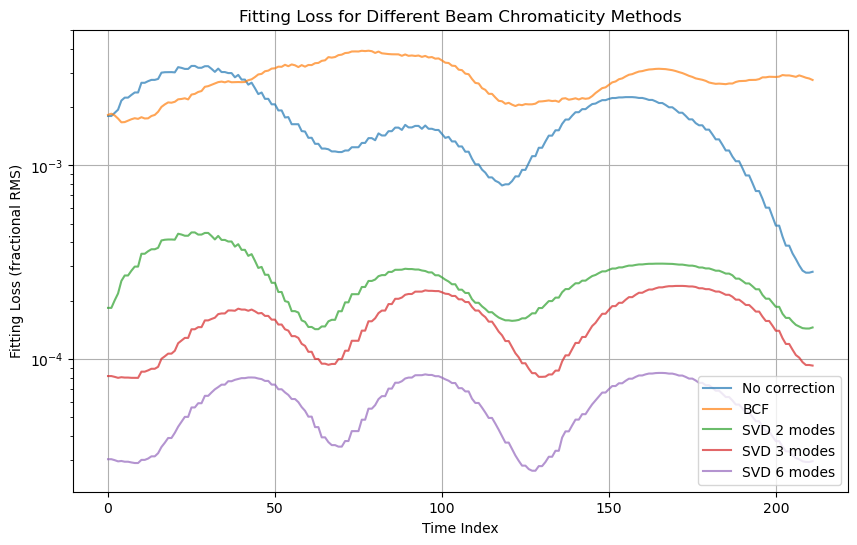

In [10]:
# Visualize the fitting loss for different beam chromaticity methods
plt.figure(figsize=(10,6))
plt.plot(RHINO_loss, label='No correction', alpha=0.7)
plt.plot(RHINO_loss_BCF, label='BCF', alpha=0.7)
plt.plot(RHINO_loss_SVD_2, label='SVD 2 modes', alpha=0.7)
plt.plot(RHINO_loss_SVD_3, label='SVD 3 modes', alpha=0.7)
plt.plot(RHINO_loss_SVD_6, label='SVD 6 modes', alpha=0.7)
plt.xlabel('Time Index')
plt.ylabel('Fitting Loss (fractional RMS)')
plt.yscale('log')
plt.legend()
plt.title('Fitting Loss for Different Beam Chromaticity Methods')
plt.grid()
plt.show()

## 3. Extract Global 21cm

Beam chromaticity is the biggest obstable..

We will try the SVD method to correct for the beam chromaticity..


In [11]:
from SEDfitting import Global_21cm_extraction

GS_object_55_85 = Global_21cm_extraction(freq_list)
true_signal = np.load('global_signal_55_85.npy')
true_signal *= 1e-3 # mK --> K

full_TOD = sky_TOD_Rhino + true_signal[np.newaxis,:] + 2.732 

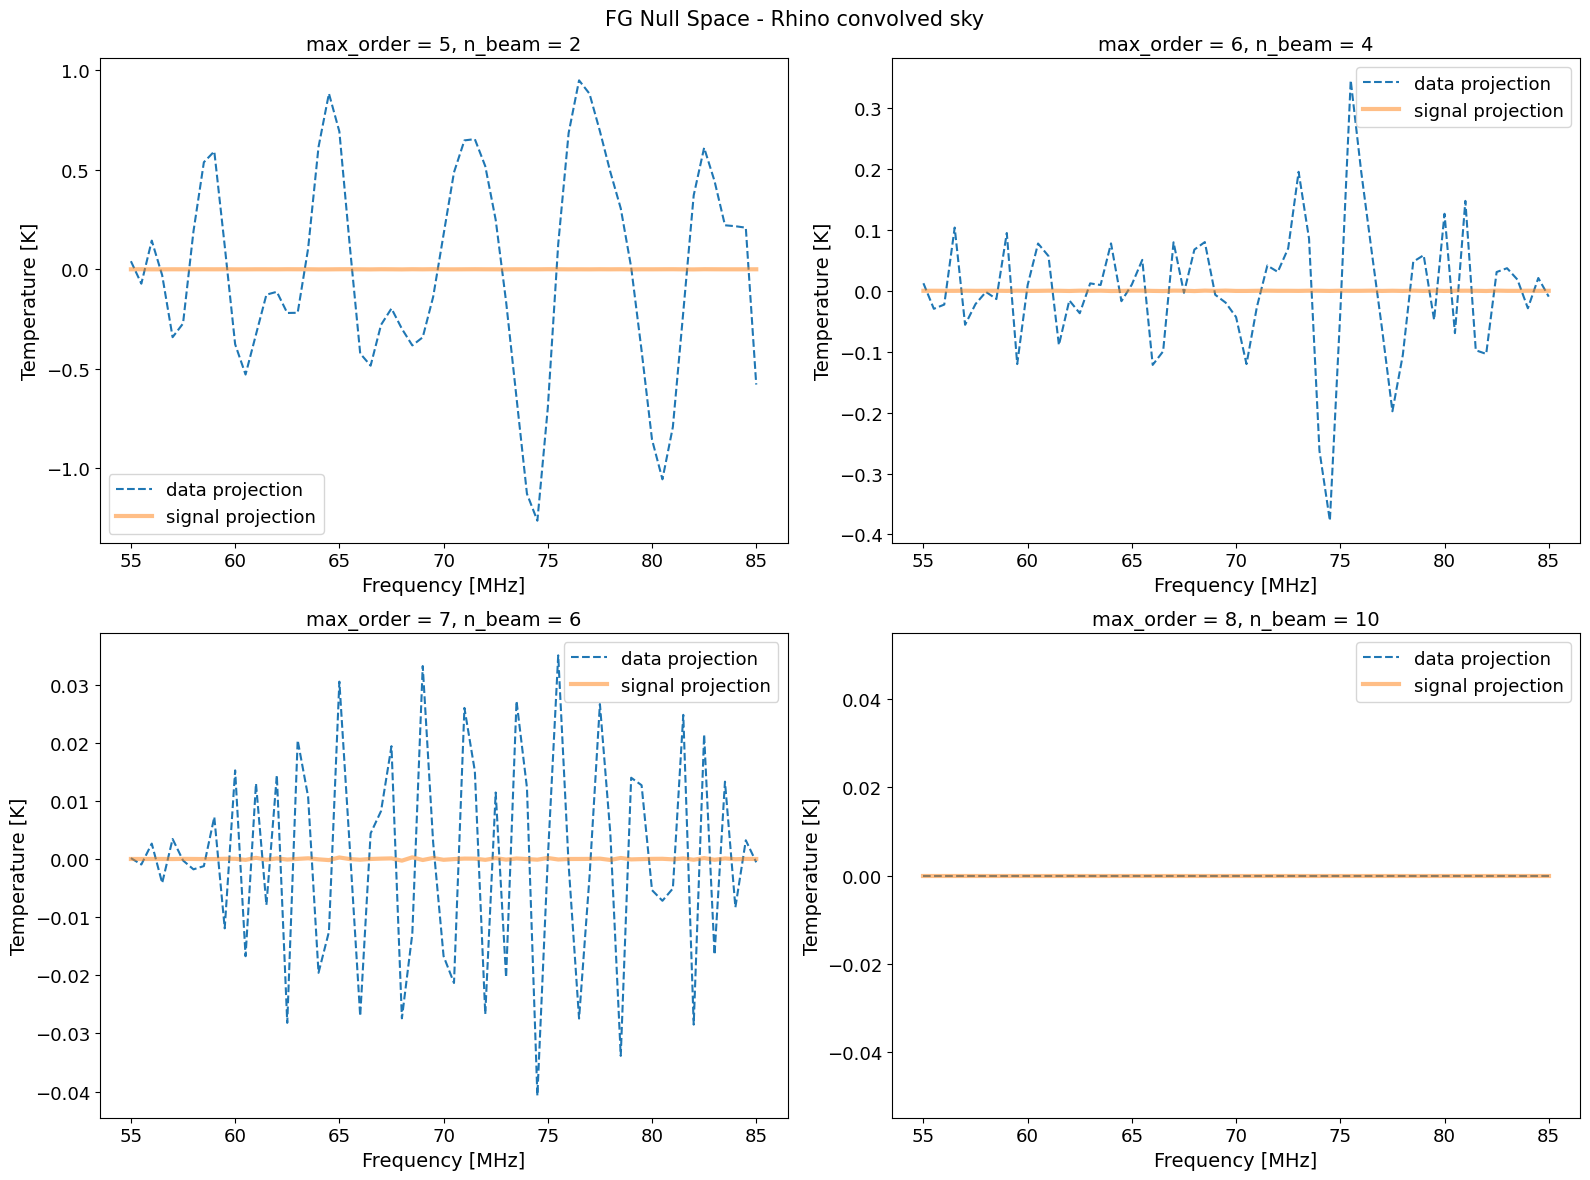

In [23]:
orders = [[5,6],[7,8]]
n_beams = [[2, 4],[6,10]]
ind = 1

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

for i in range(2):
    for j in range(2):
        max_order = orders[i][j]
        n_beam = n_beams[i][j]
        data_projs, gs_projs =  GS_object_55_85.projection_in_fg_null_space(full_TOD, pivot_specind_TOD, max_order, true_signal, BCSVD=RHINO_U[:, :n_beam])
        ax = axs[i,j]
        ax.plot(freq_list, data_projs[ind], label='data projection', linestyle='--')
        ax.plot(freq_list, gs_projs[ind], label='signal projection', lw=3, alpha=0.5)
        ax.set_ylabel('Temperature [K]', fontsize=14)
        ax.set_xlabel('Frequency [MHz]', fontsize=14)
        ax.set_title('max_order = {}, n_beam = {}'.format(max_order, n_beam), fontsize=14)
        ax.legend(fontsize=13)
for ax in axs.flat:
    ax.tick_params(axis='both', which='major', labelsize=13)
plt.suptitle('FG Null Space - Rhino convolved sky', fontsize=15)
plt.tight_layout()
plt.show()

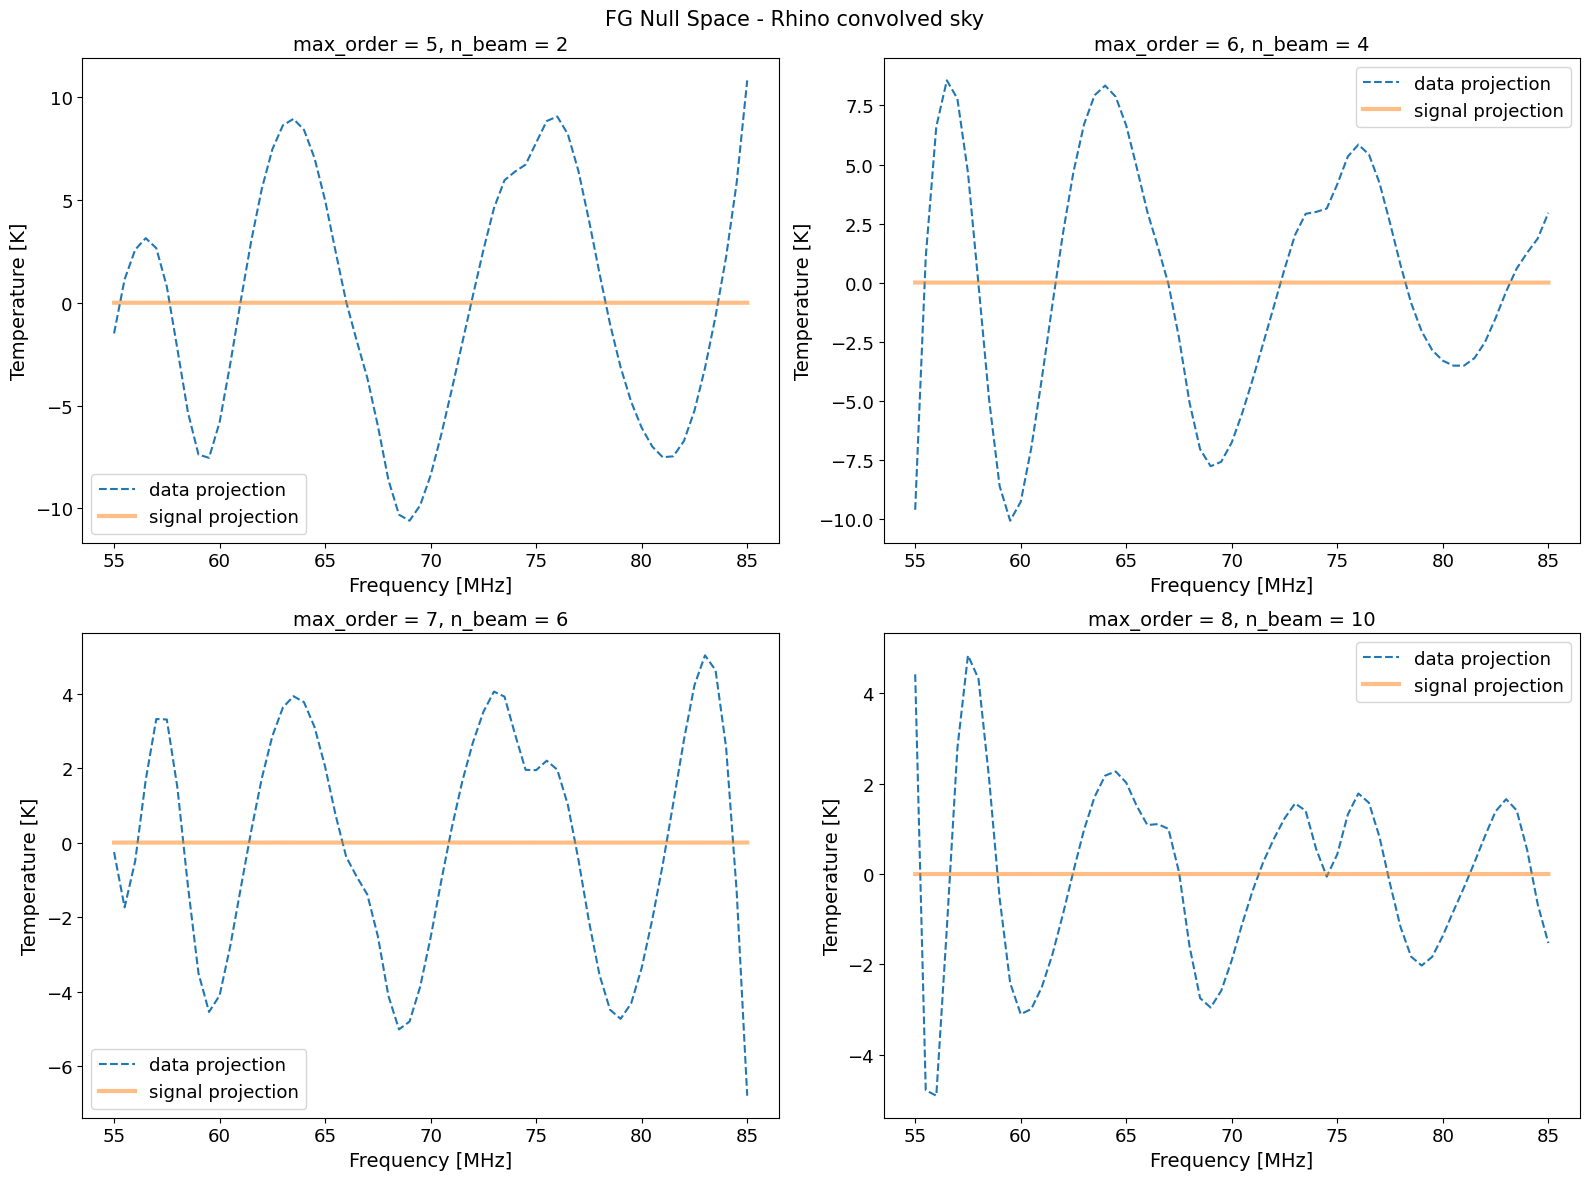

In [22]:
orders = [[5,6],[7,8]]
ind = 1

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

for i in range(2):
    for j in range(2):
        max_order = orders[i][j]
        n_beam = n_beams[i][j]
        data_projs, gs_projs =  GS_object_55_85.projection_in_fg_null_space(full_TOD, pivot_specind_TOD, max_order, true_signal, BCF_list=RHINO_BCF_cube)
        ax = axs[i,j]
        ax.plot(freq_list, data_projs[ind], label='data projection', linestyle='--')
        ax.plot(freq_list, gs_projs[ind], label='signal projection', lw=3, alpha=0.5)
        ax.set_ylabel('Temperature [K]', fontsize=14)
        ax.set_xlabel('Frequency [MHz]', fontsize=14)
        ax.set_title('max_order = {}, n_beam = {}'.format(max_order, n_beam), fontsize=14)
        ax.legend(fontsize=13)
for ax in axs.flat:
    ax.tick_params(axis='both', which='major', labelsize=13)
plt.suptitle('FG Null Space - Rhino convolved sky', fontsize=15)
plt.tight_layout()
plt.show()